<a href="https://colab.research.google.com/github/VarsanJ/Cities-in-Motion-2026/blob/main/CatBoostModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0:	learn: 2.1104668	total: 29.6ms	remaining: 29.6s
50:	learn: 1.2982351	total: 1.29s	remaining: 24s
100:	learn: 1.1778727	total: 2.56s	remaining: 22.8s
150:	learn: 1.1049773	total: 3.79s	remaining: 21.3s
200:	learn: 1.0441747	total: 5.99s	remaining: 23.8s
250:	learn: 0.9798881	total: 7.72s	remaining: 23s
300:	learn: 0.9252717	total: 8.67s	remaining: 20.1s
350:	learn: 0.8796322	total: 9.59s	remaining: 17.7s
400:	learn: 0.8363943	total: 10.5s	remaining: 15.7s
450:	learn: 0.7963695	total: 11.5s	remaining: 14s
500:	learn: 0.7592879	total: 12.7s	remaining: 12.6s
550:	learn: 0.7241408	total: 13.9s	remaining: 11.4s
600:	learn: 0.6901677	total: 15.2s	remaining: 10.1s
650:	learn: 0.6611599	total: 16.4s	remaining: 8.79s
700:	learn: 0.6292847	total: 17.9s	remaining: 7.64s
750:	learn: 0.6007226	total: 20.3s	remaining: 6.72s
800:	learn: 0.5741415	total: 22.1s	remaining: 5.5s
850:	learn: 0.5503533	total: 24.9s	remaining: 4.36s
900:	learn: 0.5278295	total: 26.4s	remaining: 2.9s
950:	learn: 0.5062285	

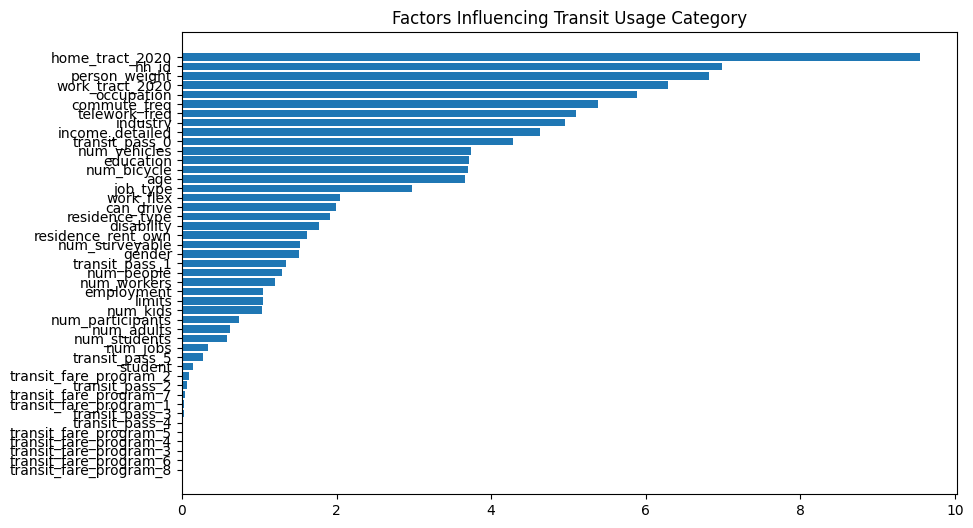


--- SHAP Summary Plot ---


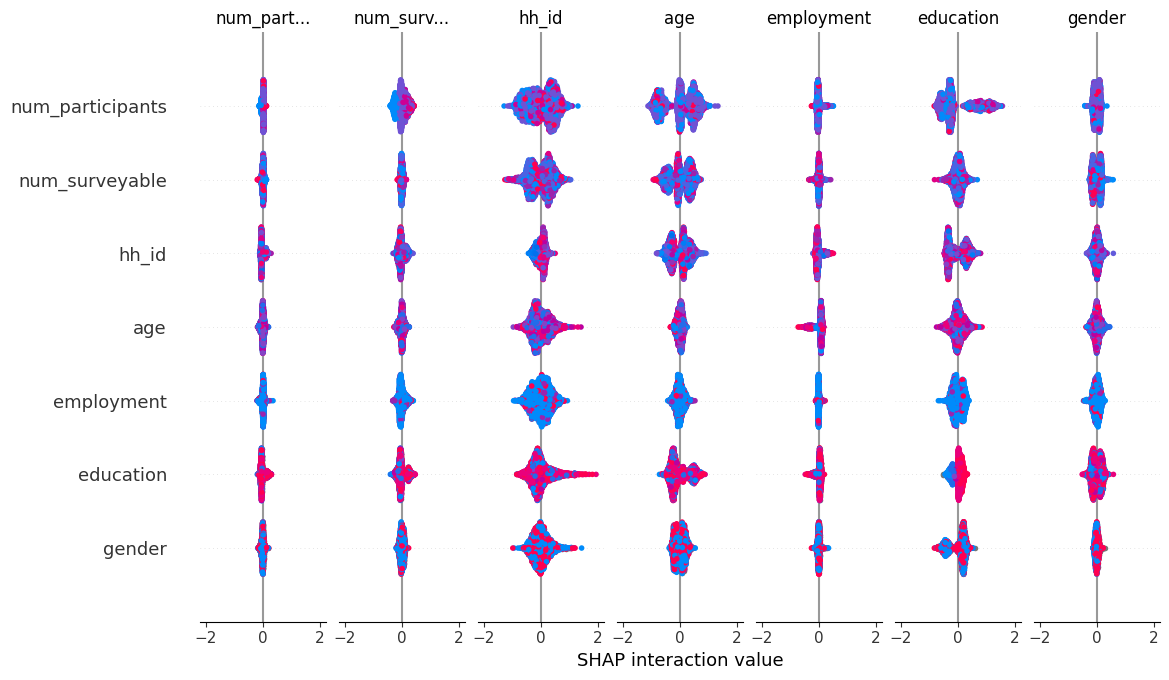


--- Partial Dependence for telework_freq ---


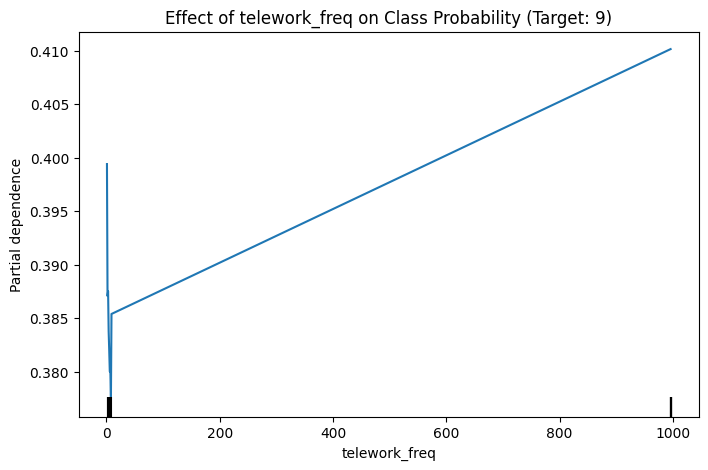

In [5]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# File Import
fileImport = pd.read_csv("CMAP_NeededVariables.csv")

# Define Columns
dependent_var = 'transit_freq'
independent_var = 'telework_freq'

# Handle Special Code Cases
fileImport_cleaned = fileImport.copy()
# Replace the 996 with 9 (Never)
fileImport_cleaned[dependent_var] = fileImport_cleaned[dependent_var].replace(996, 9)
# General custom codes for invalid responses
custom_codes = [995, 997, 998, 999, -1]
fileImport_cleaned = fileImport_cleaned.replace(custom_codes, np.nan)

# Cleans variables
df = fileImport_cleaned.dropna(subset=[dependent_var]) # Can't train on NaN targets
X = df.drop(columns=[dependent_var])
y = df[dependent_var]

# Categorical Columns
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Create Classification Model
model = CatBoostClassifier(
    iterations=1000, #
    learning_rate=0.05, #
    depth=6, #
    loss_function='MultiClass', # Use MultiClass for categorical frequency levels
    random_seed=42,
    nan_mode='Min', #
    verbose=50 # Print outputs on occasional basis #
)

# Model Training
model.fit(X, y, cat_features=cat_features)

# Feature Importance Plot
print("\n--- Feature Importance ---")
importance = model.get_feature_importance(prettified=True)
plt.figure(figsize=(10, 6))
plt.barh(importance['Feature Id'][::-1], importance['Importances'][::-1])
plt.title("Factors Influencing Transit Usage Category")
plt.show()

# SHAP Value Summary Plot
print("\n--- SHAP Summary Plot ---")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X)

# Partial Dependence Plot
print(f"\n--- Partial Dependence for {independent_var} ---")
fig, ax = plt.subplots(figsize=(8, 5))
# Determine the target class to plot (e.g., the most frequent class)
most_frequent_class = y.mode()[0]
PartialDependenceDisplay.from_estimator(model, X, features=[independent_var], ax=ax, target=most_frequent_class)
plt.title(f'Effect of {independent_var} on Class Probability (Target: {most_frequent_class})')
plt.show()